Raw Matrix Shape: (302, 142)
Total Amplitude Response Columns Found: 135
Tidy Long-Format Shape (Recorded responses only): (4248, 10)

  PHASE 4: SPATIAL MAPPING — INFLECTING AMPLITUDE SHIFTS BY JO DISTANCE

>>> Medial Cluster Spatial Profile (n = 19 Sensilla Hairs) <<<
  Unweighted Pearson r = 0.108, p = 0.6589
  Precision Weighted r = 0.255 (Correcting for sample volume bias)

  Weighted Least Squares (WLS) Linear Fit Summary Table:
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -10.9255      4.751     -2.300      0.034     -20.949      -0.902
JODistance     0.0731      0.067      1.086      0.293      -0.069       0.215

>>> Lateral Cluster Spatial Profile (n = 179 Sensilla Hairs) <<<
  Unweighted Pearson r = 0.148, p = 0.0487
  Precision Weighted r = 0.136 (Correcting for sample volume bias)

  Weighted Least Squares (WLS) Linear Fit Summary Table:
           

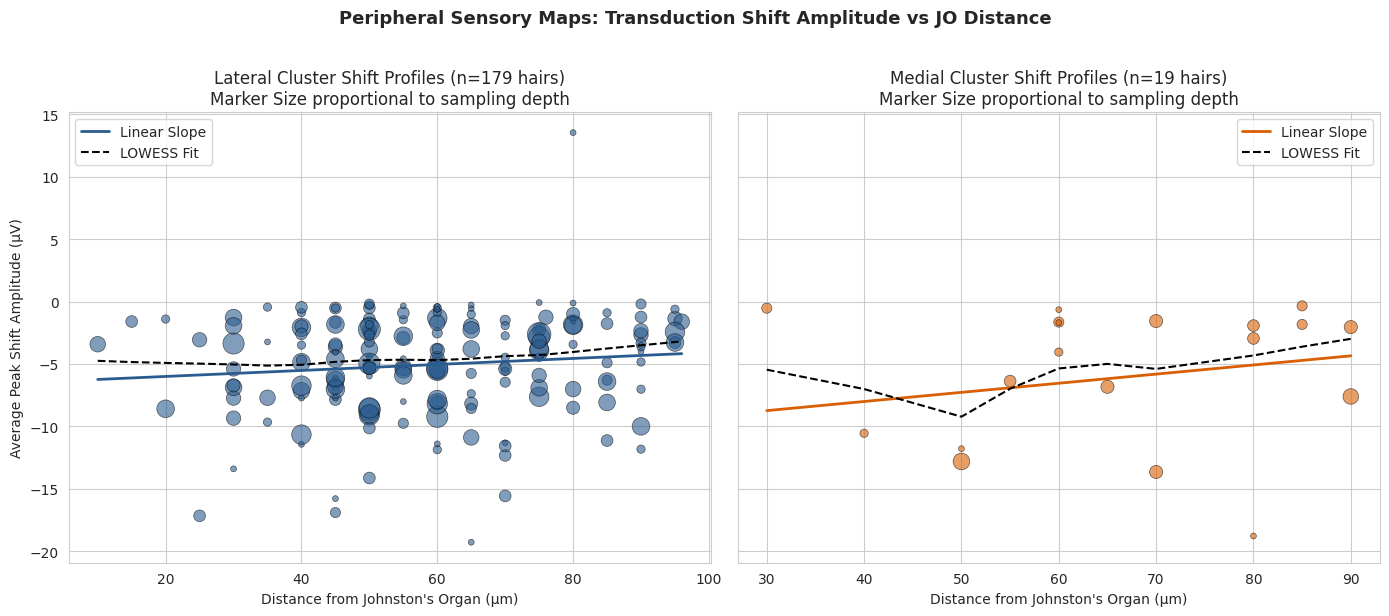


  PHASE 4b: PEAK DEFLECTION AMPLITUDE VS ELECTRODE LOCATION COORDINATES

Medial Coordinates Vector Evaluation:
  Weighted Electrode Coordinate vs Amplitude Vector r = 0.200
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -9.8529      9.194     -1.072      0.325     -32.350      12.645
ElectrodeLocation     0.0715      0.143      0.499      0.636      -0.279       0.422

Lateral Coordinates Vector Evaluation:
  Weighted Electrode Coordinate vs Amplitude Vector r = -0.013
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -4.6123      1.195     -3.860      0.000      -6.987      -2.238
ElectrodeLocation    -0.0024      0.020     -0.121      0.904      -0.043       0.038


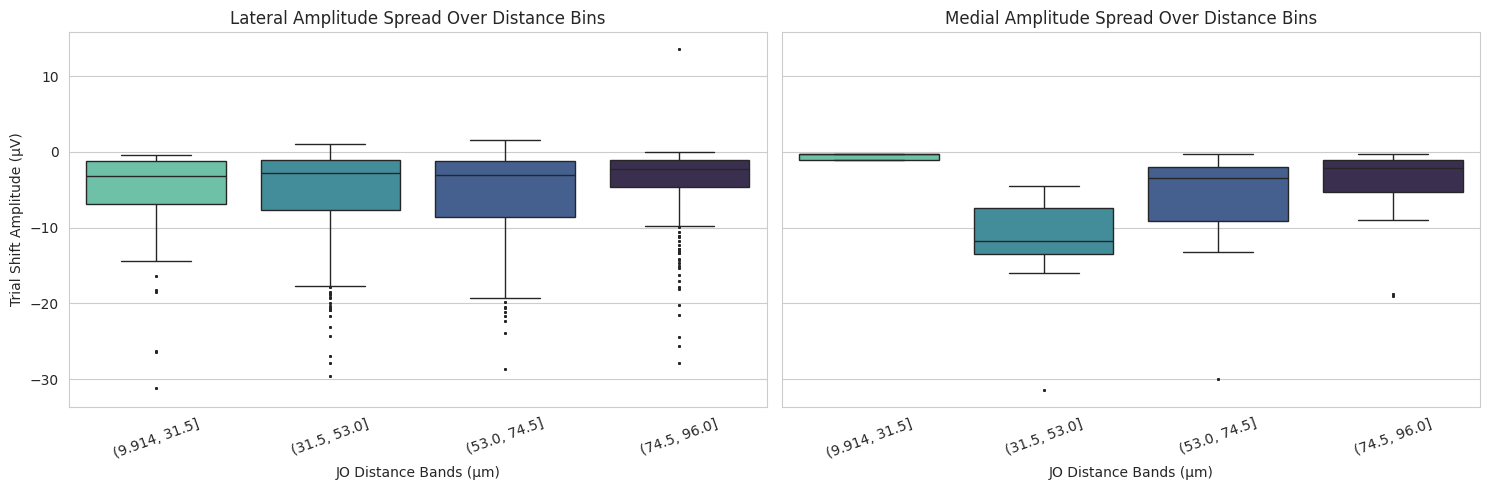


  PHASE 5: INDUCTIVE COVARIANCES — LINEAR MIXED MODELS

[LMM Output] Medial Array: Amplitude ~ JODistance + Cell Lineage (Random Intercepts: Strain)
              Coef. Std.Err.       z  P>|z|   [0.025  0.975]
Intercept    -5.949    2.444  -2.434  0.015  -10.739  -1.159
Cell[T.CpB]   0.000    0.901   0.000  1.000   -1.766   1.766
Cell[T.CpC]   0.000    0.901   0.000  1.000   -1.766   1.766
JODistance    0.036    0.030   1.220  0.223   -0.022   0.095
Group Var    11.586    1.341                                

[LMM Output] Lateral Array: Amplitude ~ JODistance + Cell Lineage (Random Intercepts: Strain)
              Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept    -6.838    0.868  -7.876  0.000  -8.540  -5.136
Cell[T.CpB]  -0.000    0.247  -0.000  1.000  -0.485   0.485
Cell[T.CpC]   0.000    0.247   0.000  1.000  -0.485   0.485
JODistance    0.039    0.006   6.638  0.000   0.027   0.050
Group Var     7.632    0.623                               

[Anatomical Interaction Matr

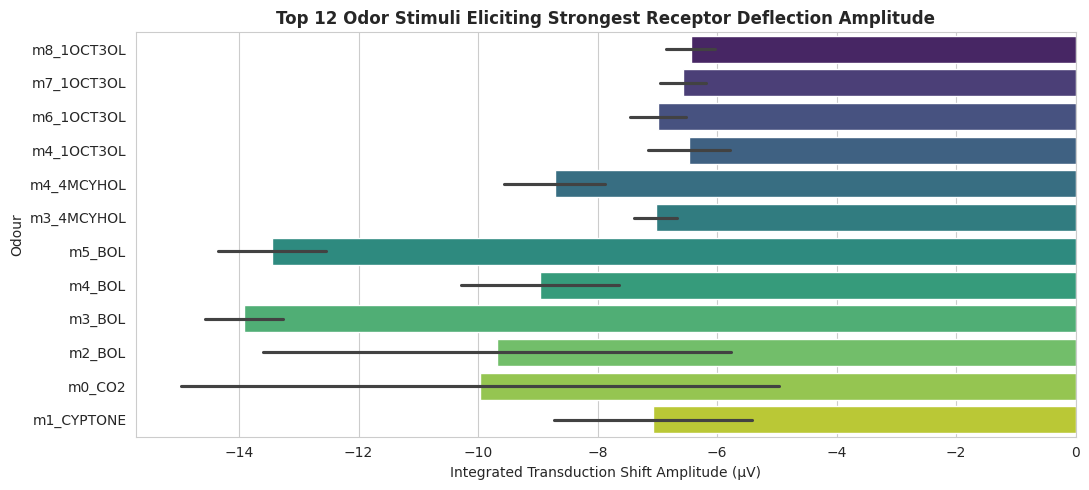

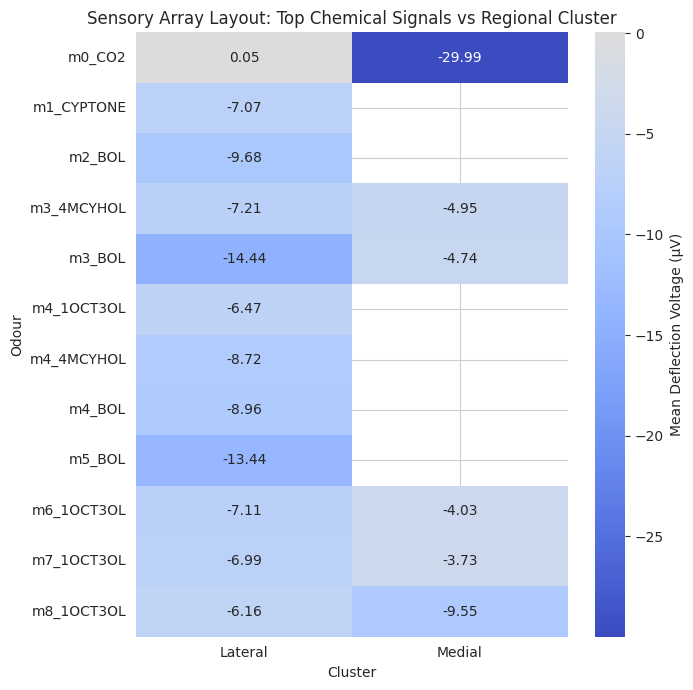


Pipeline Successfully Completed. Outputs saved cleanly to disk.


In [ ]:
# ==============================================================================
# Mosquito Maxillary Palp Sensilla — JO Distance vs Amplitude Deep Dive
# ==============================================================================
# Paste this entire script into your Colab cell.
# ==============================================================================

!pip install -q statsmodels openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)

# ----------------------------------------------------------------
# 1. LOAD & RESHAPE DATA (COMPATIBLE WITH EXCEL/CSV)
# ----------------------------------------------------------------
FILE_PATH = "Sensilla_Average_Amplitude_Summary.xlsx - Average_Amplitude.csv" ### Change if using raw .xlsx

try:
    df = pd.read_csv(FILE_PATH, header=0)
except Exception:
    df = pd.read_excel("Sensilla_Average_Amplitude_Summary.xlsx", header=0)

meta_cols = ["Strain", "Brain", "Palp", "Sensilla", "Location", "JODistance", "ElectrodeLocation"]
all_response_cols = [c for c in df.columns if c not in meta_cols]

print(f"Raw Matrix Shape: {df.shape}")
print(f"Total Amplitude Response Columns Found: {len(all_response_cols)}")

# Melt wide matrix format to tidy long format
long_df = df.melt(id_vars=meta_cols, value_vars=all_response_cols,
                  var_name="RawCol", value_name="AmplitudeResponse")

# Extract cell pedigree (CpA, CpB, CpC) and stimulus names
long_df["Cell"] = long_df["RawCol"].str.extract(r"_(Cp[ABC])$")
long_df["Odour"] = long_df["RawCol"].str.replace(r"_Cp[ABC]$", "", regex=True)
long_df = long_df.drop(columns="RawCol").dropna(subset=["AmplitudeResponse"])

print(f"Tidy Long-Format Shape (Recorded responses only): {long_df.shape}")

# ----------------------------------------------------------------
# 2. ANATOMICAL CLUSTERING & CLEANING
# ----------------------------------------------------------------
def assign_cluster(loc):
    if pd.isna(loc): return np.nan
    loc = str(loc)
    if "Medial" in loc: return "Medial"
    elif "Lateral" in loc: return "Lateral"
    return np.nan

long_df["Cluster"] = long_df["Location"].apply(assign_cluster)

# Filter down to rows containing spatial layout mappings
analysis_df = long_df.dropna(subset=["JODistance", "AmplitudeResponse", "Cluster"]).copy()
analysis_df["Strain"] = analysis_df["Strain"].astype(str).str.strip()

# Create unique tracking index per physical hair structure
analysis_df["SensillumID"] = (analysis_df["Strain"] + "|" +
                               analysis_df["Brain"].astype(str) + "|" +
                               analysis_df["Palp"].astype(str) + "|" +
                               analysis_df["Sensilla"].astype(str))

# Export long table asset
analysis_df.to_csv("amplitude_sensilla_long_tidy.csv", index=False)

# ----------------------------------------------------------------
# 3. SENSILLUM-LEVEL AGGREGATION & BIAS CORRECTION (WEIGHTING)
# ----------------------------------------------------------------
# Collapse multi-odor recordings to unique physical nodes for spatial testing
sensillum_summary = (
    analysis_df.groupby(["SensillumID", "Strain", "Cluster", "JODistance", "ElectrodeLocation"],
                         dropna=False, as_index=False)
    .agg(AvgAmplitude=("AmplitudeResponse", "mean"),
         MinAmplitude=("AmplitudeResponse", "min"), # Track maximum negative baseline plunges
         NReadings=("AmplitudeResponse", "size"))
)
sensillum_summary.to_csv("amplitude_sensillum_level_summary.csv", index=False)

def weighted_pearson(x, y, w):
    """Analytic Weighted Pearson Correlation."""
    x, y, w = np.asarray(x, float), np.asarray(y, float), np.asarray(w, float)
    mx, my = np.average(x, weights=w), np.average(y, weights=w)
    cxy = np.average((x - mx) * (y - my), weights=w)
    cxx = np.average((x - mx) ** 2, weights=w)
    cyy = np.average((y - my) ** 2, weights=w)
    return cxy / np.sqrt(cxx * cyy)

# ==============================================================================
# 4. PRIMARY ANALYSIS: SHIFT AMPLITUDE VS JO DISTANCE
# ==============================================================================
print("\n" + "="*80)
print("  PHASE 4: SPATIAL MAPPING — INFLECTING AMPLITUDE SHIFTS BY JO DISTANCE")
print("="*80)

for cluster in ["Medial", "Lateral"]:
    sub = sensillum_summary[sensillum_summary["Cluster"] == cluster]
    if len(sub) < 4:
        print(f"\nSkipping {cluster} spatial modeling due to limited sample layout.")
        continue

    r_unw, p_unw = stats.pearsonr(sub["JODistance"], sub["AvgAmplitude"])
    r_w = weighted_pearson(sub["JODistance"], sub["AvgAmplitude"], sub["NReadings"])

    print(f"\n>>> {cluster} Cluster Spatial Profile (n = {len(sub)} Sensilla Hairs) <<<")
    print(f"  Unweighted Pearson r = {r_unw:.3f}, p = {p_unw:.4f}")
    print(f"  Precision Weighted r = {r_w:.3f} (Correcting for sample volume bias)")

    try:
        wls_model = smf.wls("AvgAmplitude ~ JODistance", data=sub, weights=sub["NReadings"]).fit()
        print("\n  Weighted Least Squares (WLS) Linear Fit Summary Table:")
        print(wls_model.summary().tables[1])
    except Exception as e:
        print(f"  WLS Execution Error: {e}")

# Visualization: Weighted Bubble Matrix with Linear Trends & LOWESS curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, cluster, color in zip(axes, ["Lateral", "Medial"], ["#2b5c8f", "#d95f02"]):
    sub = sensillum_summary[sensillum_summary["Cluster"] == cluster]
    ax.scatter(sub["JODistance"], sub["AvgAmplitude"],
               s=sub["NReadings"] * 6, alpha=0.6, color=color,
               edgecolor="black", linewidth=0.5)

    if len(sub) >= 4:
        # Fit Linear regression
        wls_model = smf.wls("AvgAmplitude ~ JODistance", data=sub, weights=sub["NReadings"]).fit()
        xs = np.linspace(sub["JODistance"].min(), sub["JODistance"].max(), 100)
        pred = wls_model.predict(pd.DataFrame({"JODistance": xs}))
        ax.plot(xs, pred, color=color, linewidth=2, label="Linear Slope")

        # Fit Local Non-Parametric Trend line
        lowess = sm.nonparametric.lowess(sub["AvgAmplitude"], sub["JODistance"], frac=0.65)
        ax.plot(lowess[:, 0], lowess[:, 1], color="black", linestyle="--", linewidth=1.5, label="LOWESS Fit")

    ax.set_title(f"{cluster} Cluster Shift Profiles (n={len(sub)} hairs)\nMarker Size proportional to sampling depth")
    ax.set_xlabel("Distance from Johnston's Organ (μm)")
    ax.legend(frameon=True)

axes[0].set_ylabel("Average Peak Shift Amplitude (μV)")
fig.suptitle("Peripheral Sensory Maps: Transduction Shift Amplitude vs JO Distance", y=1.02, fontsize=13, weight='bold')
plt.tight_layout()
plt.savefig("amplitude_analysis_jodistance_spatial.png", dpi=150, bbox_inches="tight")
plt.show()

# ----------------------------------------------------------------
# 4b. SECONDARY GEOMETRIC CHECK: COORD LOCATION ANALYSIS
# ----------------------------------------------------------------
print("\n" + "="*80)
print("  PHASE 4b: PEAK DEFLECTION AMPLITUDE VS ELECTRODE LOCATION COORDINATES")
print("="*80)

el_summary = sensillum_summary.dropna(subset=["ElectrodeLocation"])
for cluster in ["Medial", "Lateral"]:
    sub = el_summary[el_summary["Cluster"] == cluster]
    if len(sub) < 4: continue

    r_w = weighted_pearson(sub["ElectrodeLocation"], sub["AvgAmplitude"], sub["NReadings"])
    print(f"\n{cluster} Coordinates Vector Evaluation:")
    print(f"  Weighted Electrode Coordinate vs Amplitude Vector r = {r_w:.3f}")
    try:
        wls_el = smf.wls("AvgAmplitude ~ ElectrodeLocation", data=sub, weights=sub["NReadings"]).fit()
        print(wls_el.summary().tables[1])
    except Exception as e: print(f"WLS coordinate evaluation faulted: {e}")

# ----------------------------------------------------------------
# 4c. COARSE BOX-DIAGNOSTIC TRACKING ACROSS SPATIAL SECTORS
# ----------------------------------------------------------------
analysis_df["JODistanceBin"] = pd.cut(analysis_df["JODistance"], bins=4)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, cluster in zip(axes, ["Lateral", "Medial"]):
    sub = analysis_df[analysis_df["Cluster"] == cluster]
    sns.boxplot(data=sub, x="JODistanceBin", y="AmplitudeResponse", ax=ax, palette="mako_r", fliersize=1)
    ax.set_title(f"{cluster} Amplitude Spread Over Distance Bins")
    ax.set_xlabel("JO Distance Bands (μm)")
    ax.tick_params(axis="x", rotation=20)
axes[0].set_ylabel("Trial Shift Amplitude (μV)")
plt.tight_layout()
plt.savefig("amplitude_variance_brackets.png", dpi=150)
plt.show()

# ==============================================================================
# 5. MIXED-EFFECTS MODELS: COMBINED ANATOMICAL CONTROLS
# ==============================================================================
print("\n" + "="*80)
print("  PHASE 5: INDUCTIVE COVARIANCES — LINEAR MIXED MODELS")
print("="*80)

for cluster in ["Medial", "Lateral"]:
    sub = analysis_df[analysis_df["Cluster"] == cluster].copy()
    if sub["Strain"].nunique() < 2 or len(sub) < 15:
        print(f"\nSkipping LMM analysis for {cluster} due to insufficient strain groupings.")
        continue

    print(f"\n[LMM Output] {cluster} Array: Amplitude ~ JODistance + Cell Lineage (Random Intercepts: Strain)")
    try:
        model = smf.mixedlm("AmplitudeResponse ~ JODistance + Cell", data=sub, groups=sub["Strain"])
        print(model.fit(reml=True).summary().tables[1])
    except Exception as e: print(f"LMM Convergence Failed: {e}")

print("\n[Anatomical Interaction Matrix] Evaluating Structural Convergence Shifts between Clusters:")
try:
    inter_model = smf.mixedlm("AmplitudeResponse ~ JODistance * Cluster", data=analysis_df, groups=analysis_df["Strain"])
    print(inter_model.fit(reml=True).summary())
except Exception as e: print(f"Structural cross interaction calculation failed: {e}")

# ==============================================================================
# 6. SENSORY TUNING CHARACTERISTICS
# ==============================================================================
print("\n" + "="*80)
print("  PHASE 6: RECEPTOR METRICS SUMMARY (ODOR SPECTRA AND PHENOTYPES)")
print("="*80)

# --- 6a. Mean Response Profiles per Odor ---
odour_summary = analysis_df.groupby("Odour")["AmplitudeResponse"].agg(["mean", "std", "count"])
# Target the top 12 odors based on absolute shift scale
top_odours = odour_summary[odour_summary["count"] >= 5].assign(abs_mean=odour_summary["mean"].abs()).sort_values("abs_mean", ascending=False).head(12).index

plt.figure(figsize=(11, 5))
sns.barplot(data=analysis_df[analysis_df["Odour"].isin(top_odours)], y="Odour", x="AmplitudeResponse", errorbar="se", palette="viridis")
plt.title("Top 12 Odor Stimuli Eliciting Strongest Receptor Deflection Amplitude", weight='bold')
plt.xlabel("Integrated Transduction Shift Amplitude (μV)")
plt.tight_layout()
plt.savefig("amplitude_top_odors_profile.png", dpi=150)
plt.show()

# --- 6b. Spatial Receptor Distribution Maps (Heatmaps) ---
pivot = analysis_df[analysis_df["Odour"].isin(top_odours)].groupby(["Odour", "Cluster"])["AmplitudeResponse"].mean().unstack()
plt.figure(figsize=(7, 7))
sns.heatmap(pivot, cmap="coolwarm", center=0, annot=True, fmt=".2f", cbar_kws={'label': 'Mean Deflection Voltage (μV)'})
plt.title("Sensory Array Layout: Top Chemical Signals vs Regional Cluster")
plt.tight_layout()
plt.savefig("amplitude_spatial_odor_heatmap.png", dpi=150)
plt.show()

print("\n" + "="*80)
print("Pipeline Successfully Completed. Outputs saved cleanly to disk.")
print("="*80)

Raw Matrix Shape: (302, 142)
Total Amplitude Columns Found: 135
Tidy Long-Format Shape (Recorded responses only): (4248, 10)
Filtered rows usable for spatial mapping (JO or Electrode): 3504

  PHASE 4: SPATIAL MAPPING — DRIVING AMPLITUDE SHIFTS BY JO DISTANCE

>>> Medial Cluster JO Profile (n = 19 Sensilla Hairs) <<<
  Unweighted Pearson r = 0.108, p = 0.6589
  Precision Weighted r = 0.255 (Correcting for sample volume bias)

  Weighted Least Squares (WLS) Linear Fit Summary Table:
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -10.9255      4.751     -2.300      0.034     -20.949      -0.902
JODistance     0.0731      0.067      1.086      0.293      -0.069       0.215

>>> Lateral Cluster JO Profile (n = 179 Sensilla Hairs) <<<
  Unweighted Pearson r = 0.148, p = 0.0487
  Precision Weighted r = 0.136 (Correcting for sample volume bias)

  Weighted Least Squares 

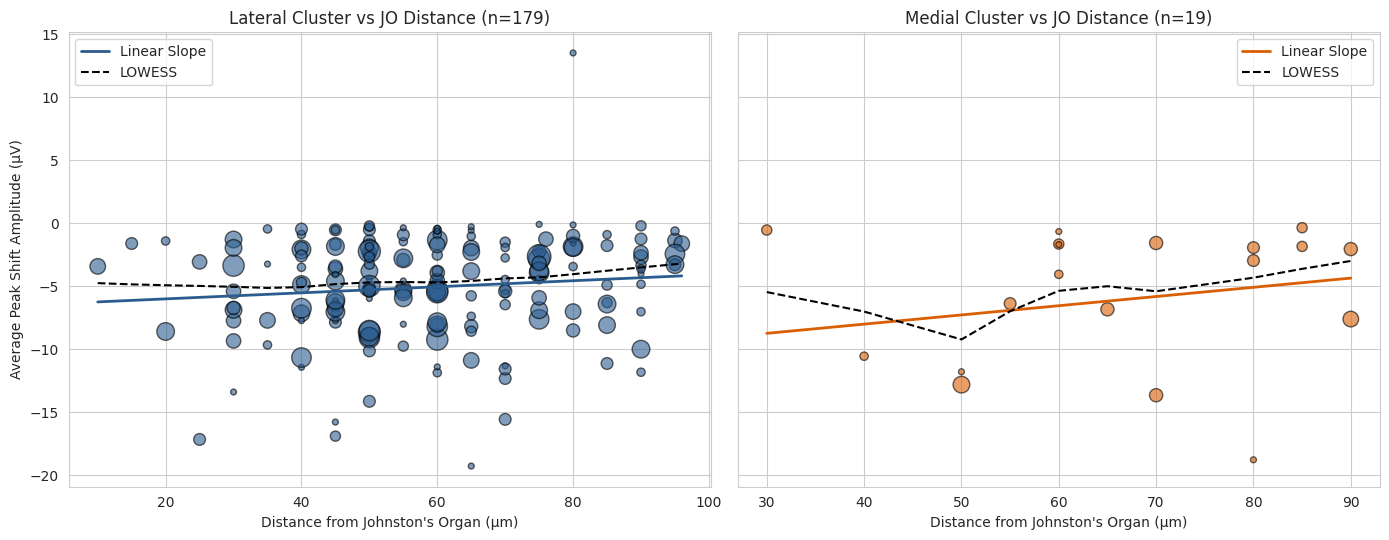


  PHASE 4b: PEAK DEFLECTION AMPLITUDE VS ELECTRODE LOCATION COORDINATES

>>> Medial Coordinates Vector Evaluation (n = 25 Sensilla Hairs) <<<
  Unweighted Pearson r = 0.137, p = 0.5152
  Precision Weighted r = -0.086 (Correcting for sample volume bias)

  Weighted Least Squares (WLS) Linear Fit Summary Table:
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -2.6227      7.147     -0.367      0.717     -17.408      12.163
ElectrodeLocation    -0.0459      0.111     -0.415      0.682      -0.275       0.183

>>> Lateral Coordinates Vector Evaluation (n = 115 Sensilla Hairs) <<<
  Unweighted Pearson r = 0.033, p = 0.7247
  Precision Weighted r = -0.020 (Correcting for sample volume bias)

  Weighted Least Squares (WLS) Linear Fit Summary Table:
                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------

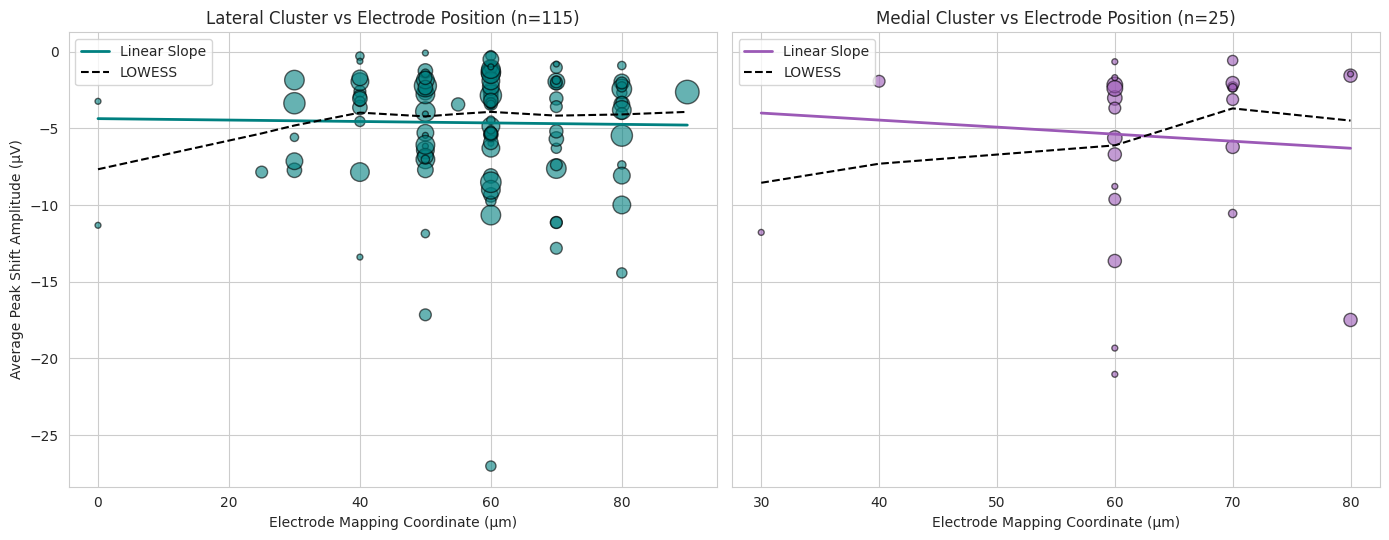

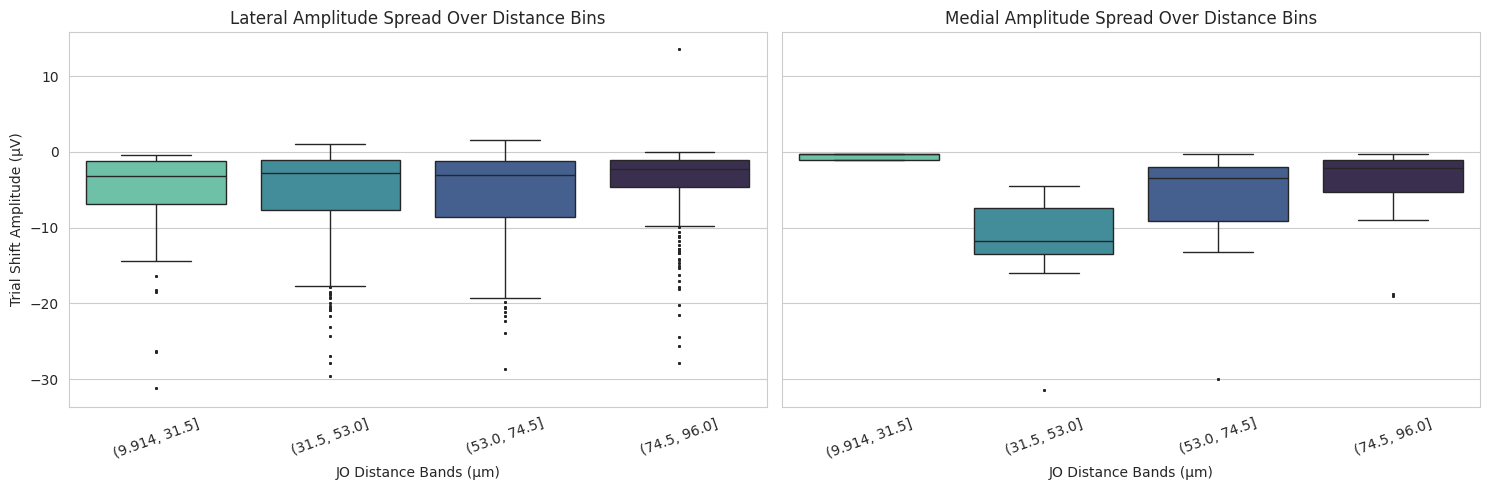


  PHASE 5: INDUCTIVE COVARIANCES — LINEAR MIXED MODELS

[LMM Output] Medial Array: Amplitude ~ JODistance + Cell Lineage (Random Intercepts: Strain)
              Coef. Std.Err.       z  P>|z|   [0.025  0.975]
Intercept    -5.949    2.444  -2.434  0.015  -10.739  -1.159
Cell[T.CpB]   0.000    0.901   0.000  1.000   -1.766   1.766
Cell[T.CpC]   0.000    0.901   0.000  1.000   -1.766   1.766
JODistance    0.036    0.030   1.220  0.223   -0.022   0.095
Group Var    11.586    1.341                                

[LMM Output] Lateral Array: Amplitude ~ JODistance + Cell Lineage (Random Intercepts: Strain)
              Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept    -6.838    0.868  -7.876  0.000  -8.540  -5.136
Cell[T.CpB]  -0.000    0.247  -0.000  1.000  -0.485   0.485
Cell[T.CpC]   0.000    0.247   0.000  1.000  -0.485   0.485
JODistance    0.039    0.006   6.638  0.000   0.027   0.050
Group Var     7.632    0.623                               

[Anatomical Interaction Matr

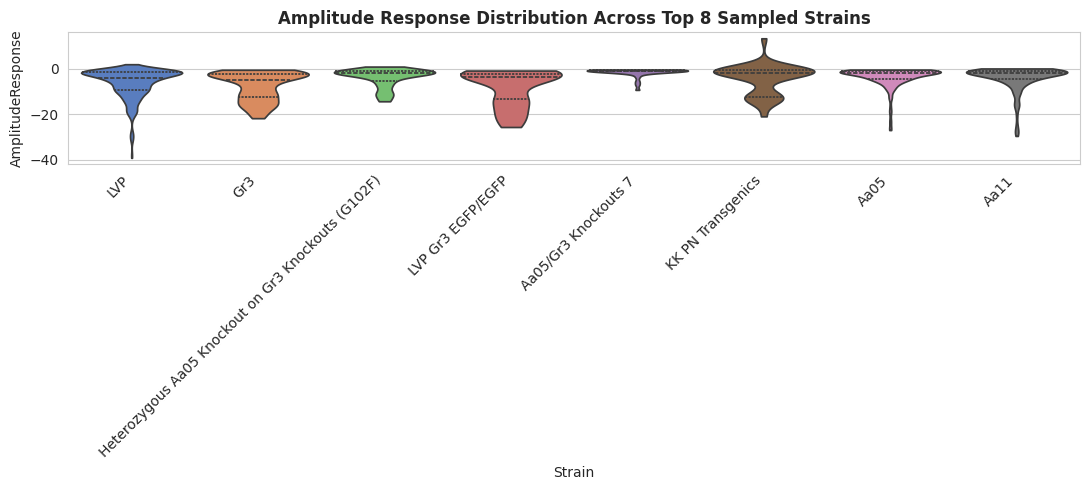

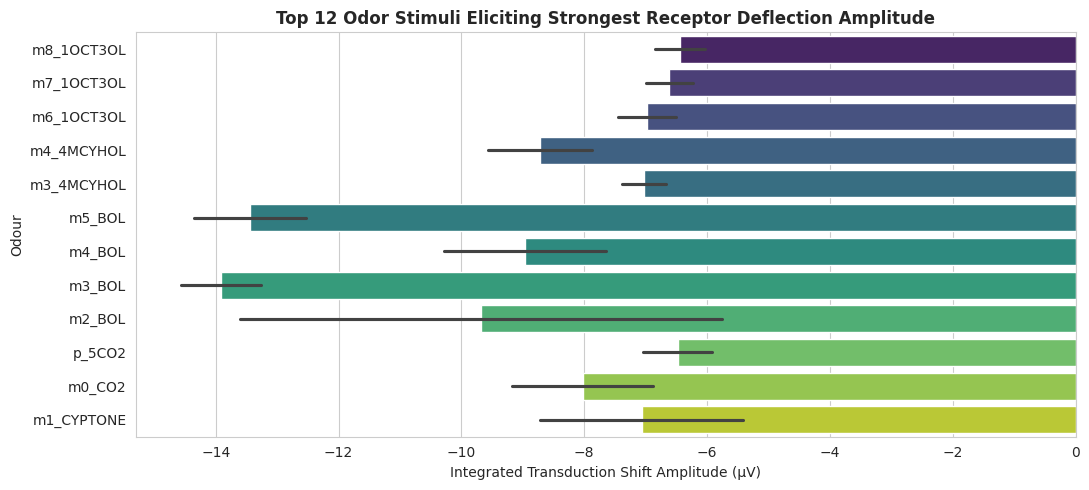


Lineage Specific Integration Capacity Matrix:
                  mean       std  count
Cluster Cell                           
Lateral CpA  -4.973732  5.869216   1036
        CpB  -4.973732  5.869216   1036
        CpC  -4.973732  5.869216   1036
Medial  CpA  -5.769747  6.756052    132
        CpB  -5.769747  6.756052    132
        CpC  -5.769747  6.756052    132


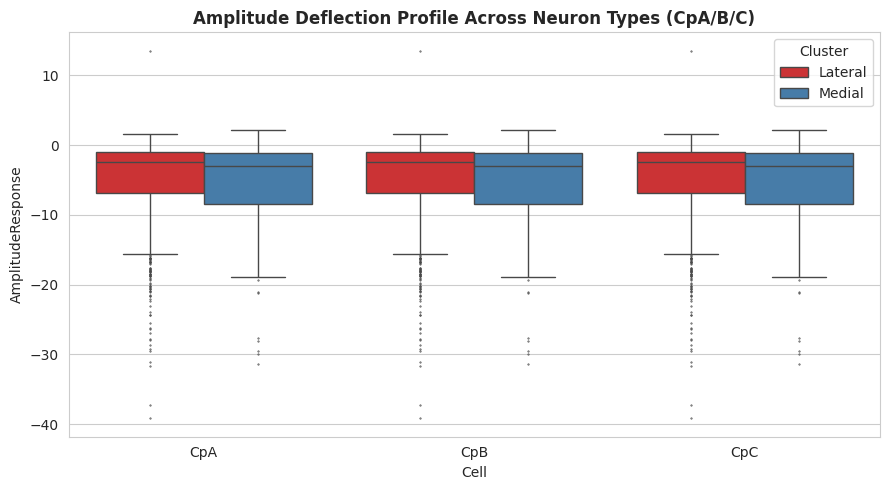

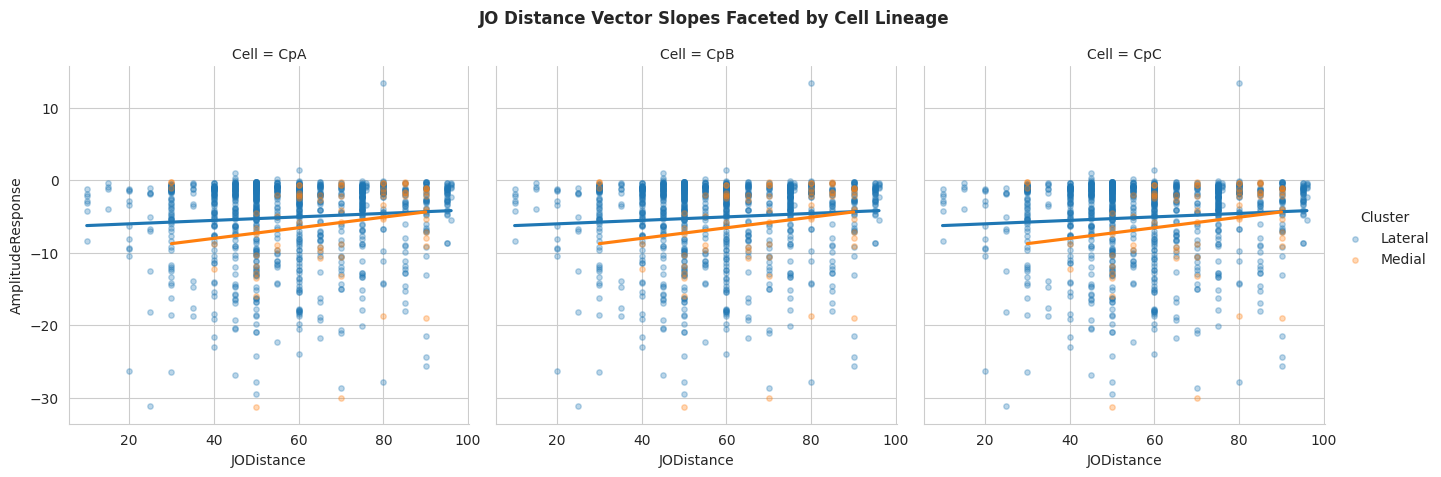

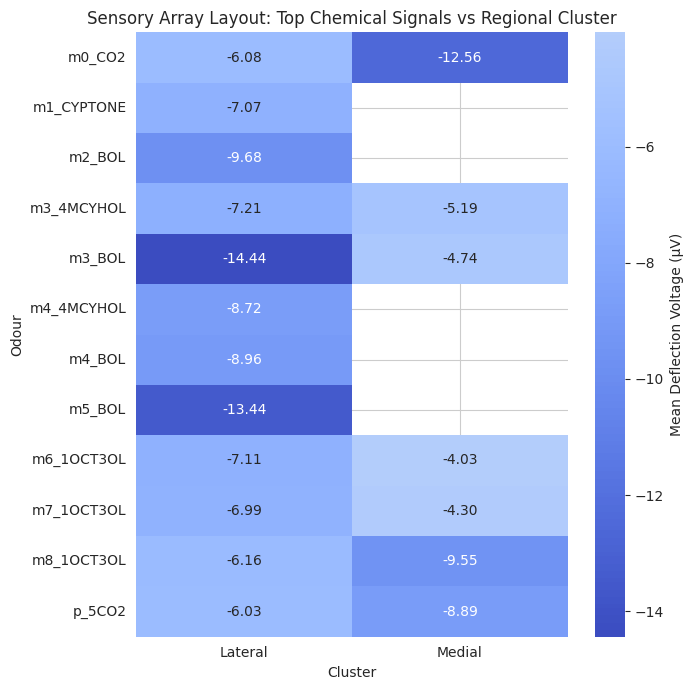


Pipeline Successfully Completed. Complete diagnostic outputs saved to disk.


In [ ]:
# ==============================================================================
# Mosquito Maxillary Palp Sensilla — Amplitude Spatial Deep Dive (Inclusive)
# ==============================================================================
# Paste this entire script into your Colab cell.
# ==============================================================================

!pip install -q statsmodels openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)

# ----------------------------------------------------------------
# 1. LOAD & RESHAPE DATA (COMPATIBLE WITH EXCEL/CSV)
# ----------------------------------------------------------------
FILE_PATH = "Sensilla_Average_Amplitude_Summary.xlsx - Average_Amplitude.csv"

try:
    df = pd.read_csv(FILE_PATH, header=0)
except Exception:
    df = pd.read_excel("Sensilla_Average_Amplitude_Summary.xlsx", header=0)

meta_cols = ["Strain", "Brain", "Palp", "Sensilla", "Location", "JODistance", "ElectrodeLocation"]
all_response_cols = [c for c in df.columns if c not in meta_cols]

print(f"Raw Matrix Shape: {df.shape}")
print(f"Total Amplitude Columns Found: {len(all_response_cols)}")

# Melt wide matrix format to tidy long format
long_df = df.melt(id_vars=meta_cols, value_vars=all_response_cols,
                  var_name="RawCol", value_name="AmplitudeResponse")

# Extract cell pedigree (CpA, CpB, CpC) and stimulus names
long_df["Cell"] = long_df["RawCol"].str.extract(r"_(Cp[ABC])$")
long_df["Odour"] = long_df["RawCol"].str.replace(r"_Cp[ABC]$", "", regex=True)
long_df = long_df.drop(columns="RawCol").dropna(subset=["AmplitudeResponse"])

print(f"Tidy Long-Format Shape (Recorded responses only): {long_df.shape}")

# ----------------------------------------------------------------
# 2. ANATOMICAL CLUSTERING & SMART INCLUSIVE FILTERS
# ----------------------------------------------------------------
def assign_cluster(loc):
    if pd.isna(loc): return np.nan
    loc = str(loc)
    if "Medial" in loc: return "Medial"
    elif "Lateral" in loc: return "Lateral"
    return np.nan

long_df["Cluster"] = long_df["Location"].apply(assign_cluster)

# CRITICAL STRATEGY SHIFT: Keep rows if they have EITHER JODistance OR ElectrodeLocation.
# We do not drop a row from the entire pipeline just because one spatial metric is missing.
analysis_df = long_df.dropna(subset=["Cluster"]).copy()
analysis_df = analysis_df[analysis_df["JODistance"].notna() | analysis_df["ElectrodeLocation"].notna()]
analysis_df["Strain"] = analysis_df["Strain"].astype(str).str.strip()

# Create unique tracking index per physical hair structure
analysis_df["SensillumID"] = (analysis_df["Strain"] + "|" +
                               analysis_df["Brain"].astype(str) + "|" +
                               analysis_df["Palp"].astype(str) + "|" +
                               analysis_df["Sensilla"].astype(str))

# Export long table asset
analysis_df.to_csv("amplitude_sensilla_long_tidy.csv", index=False)
print(f"Filtered rows usable for spatial mapping (JO or Electrode): {analysis_df.shape[0]}")

# ----------------------------------------------------------------
# 3. SENSILLUM-LEVEL AGGREGATION & BIAS CORRECTION (WEIGHTING)
# ----------------------------------------------------------------
# Collapse multi-odor recordings to unique physical nodes for spatial testing, passing NaNs safely
sensillum_summary = (
    analysis_df.groupby(["SensillumID", "Strain", "Cluster", "JODistance", "ElectrodeLocation"],
                         dropna=False, as_index=False)
    .agg(AvgAmplitude=("AmplitudeResponse", "mean"),
         MinAmplitude=("AmplitudeResponse", "min"),
         NReadings=("AmplitudeResponse", "size"))
)
sensillum_summary.to_csv("amplitude_sensillum_level_summary.csv", index=False)

def weighted_pearson(x, y, w):
    """Analytic Weighted Pearson Correlation."""
    x, y, w = np.asarray(x, float), np.asarray(y, float), np.asarray(w, float)
    mx, my = np.average(x, weights=w), np.average(y, weights=w)
    cxy = np.average((x - mx) * (y - my), weights=w)
    cxx = np.average((x - mx) ** 2, weights=w)
    cyy = np.average((y - my) ** 2, weights=w)
    return cxy / np.sqrt(cxx * cyy)

# ==============================================================================
# 4. PRIMARY ANALYTICAL BLOCK: SPATIAL MODELING
# ==============================================================================
print("\n" + "="*80)
print("  PHASE 4: SPATIAL MAPPING — DRIVING AMPLITUDE SHIFTS BY JO DISTANCE")
print("="*80)

# Isolate subset explicitly containing JO Distances
jo_summary = sensillum_summary.dropna(subset=["JODistance"])

for cluster in ["Medial", "Lateral"]:
    sub = jo_summary[jo_summary["Cluster"] == cluster]
    if len(sub) < 4:
        print(f"\nSkipping {cluster} JO spatial modeling due to limited sample layout.")
        continue

    r_unw, p_unw = stats.pearsonr(sub["JODistance"], sub["AvgAmplitude"])
    r_w = weighted_pearson(sub["JODistance"], sub["AvgAmplitude"], sub["NReadings"])

    print(f"\n>>> {cluster} Cluster JO Profile (n = {len(sub)} Sensilla Hairs) <<<")
    print(f"  Unweighted Pearson r = {r_unw:.3f}, p = {p_unw:.4f}")
    print(f"  Precision Weighted r = {r_w:.3f} (Correcting for sample volume bias)")

    try:
        wls_model = smf.wls("AvgAmplitude ~ JODistance", data=sub, weights=sub["NReadings"]).fit()
        print("\n  Weighted Least Squares (WLS) Linear Fit Summary Table:")
        print(wls_model.summary().tables[1])
    except Exception as e:
        print(f"  WLS Execution Error: {e}")

# Plot 1: Amplitude vs JO Distance (Bubble Plots + LOWESS Trends)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
for ax, cluster, color in zip(axes, ["Lateral", "Medial"], ["#2b5c8f", "#d95f02"]):
    sub = jo_summary[jo_summary["Cluster"] == cluster]
    ax.scatter(sub["JODistance"], sub["AvgAmplitude"], s=sub["NReadings"] * 6, alpha=0.6, color=color, edgecolor="black")
    if len(sub) >= 4:
        wls_model = smf.wls("AvgAmplitude ~ JODistance", data=sub, weights=sub["NReadings"]).fit()
        xs = np.linspace(sub["JODistance"].min(), sub["JODistance"].max(), 100)
        ax.plot(xs, wls_model.predict(pd.DataFrame({"JODistance": xs})), color=color, linewidth=2, label="Linear Slope")
        lowess = sm.nonparametric.lowess(sub["AvgAmplitude"], sub["JODistance"], frac=0.65)
        ax.plot(lowess[:, 0], lowess[:, 1], color="black", linestyle="--", linewidth=1.5, label="LOWESS")
    ax.set_title(f"{cluster} Cluster vs JO Distance (n={len(sub)})")
    ax.set_xlabel("Distance from Johnston's Organ (μm)")
    ax.legend(frameon=True)
axes[0].set_ylabel("Average Peak Shift Amplitude (μV)")
plt.tight_layout()
plt.savefig("amplitude_vs_jodistance.png", dpi=150)
plt.show()

# ----------------------------------------------------------------
# 4b. SECONDARY GEOMETRIC CHECK: INCLUSIVE ELECTRODE LOCATION ANALYSIS
# ----------------------------------------------------------------
print("\n" + "="*80)
print("  PHASE 4b: PEAK DEFLECTION AMPLITUDE VS ELECTRODE LOCATION COORDINATES")
print("="*80)

# Isolate subset explicitly containing Electrode Position Coordinates
el_summary = sensillum_summary.dropna(subset=["ElectrodeLocation"])

for cluster in ["Medial", "Lateral"]:
    sub = el_summary[el_summary["Cluster"] == cluster]
    if len(sub) < 4:
        print(f"\nSkipping {cluster} electrode position modeling due to limited sample layout.")
        continue

    r_unw, p_unw = stats.pearsonr(sub["ElectrodeLocation"], sub["AvgAmplitude"])
    r_w = weighted_pearson(sub["ElectrodeLocation"], sub["AvgAmplitude"], sub["NReadings"])
    print(f"\n>>> {cluster} Coordinates Vector Evaluation (n = {len(sub)} Sensilla Hairs) <<<")
    print(f"  Unweighted Pearson r = {r_unw:.3f}, p = {p_unw:.4f}")
    print(f"  Precision Weighted r = {r_w:.3f} (Correcting for sample volume bias)")
    try:
        wls_el = smf.wls("AvgAmplitude ~ ElectrodeLocation", data=sub, weights=sub["NReadings"]).fit()
        print("\n  Weighted Least Squares (WLS) Linear Fit Summary Table:")
        print(wls_el.summary().tables[1])
    except Exception as e: print(f"WLS coordinate evaluation faulted: {e}")

# Plot 2: Amplitude vs Electrode Location
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
for ax, cluster, color in zip(axes, ["Lateral", "Medial"], ["#008080", "#9b59b6"]):
    sub = el_summary[el_summary["Cluster"] == cluster]
    ax.scatter(sub["ElectrodeLocation"], sub["AvgAmplitude"], s=sub["NReadings"] * 6, alpha=0.6, color=color, edgecolor="black")
    if len(sub) >= 4:
        wls_model = smf.wls("AvgAmplitude ~ ElectrodeLocation", data=sub, weights=sub["NReadings"]).fit()
        xs = np.linspace(sub["ElectrodeLocation"].min(), sub["ElectrodeLocation"].max(), 100)
        ax.plot(xs, wls_model.predict(pd.DataFrame({"ElectrodeLocation": xs})), color=color, linewidth=2, label="Linear Slope")
        lowess = sm.nonparametric.lowess(sub["AvgAmplitude"], sub["ElectrodeLocation"], frac=0.65)
        ax.plot(lowess[:, 0], lowess[:, 1], color="black", linestyle="--", linewidth=1.5, label="LOWESS")
    ax.set_title(f"{cluster} Cluster vs Electrode Position (n={len(sub)})")
    ax.set_xlabel("Electrode Mapping Coordinate (μm)")
    ax.legend(frameon=True)
axes[0].set_ylabel("Average Peak Shift Amplitude (μV)")
plt.tight_layout()
plt.savefig("amplitude_vs_electrodelocation.png", dpi=150)
plt.show()

# ----------------------------------------------------------------
# 4c. COARSE BOX-DIAGNOSTIC TRACKING ACROSS SPATIAL SECTORS
# ----------------------------------------------------------------
jo_analysis_df = analysis_df.dropna(subset=["JODistance"]).copy()
jo_analysis_df["JODistanceBin"] = pd.cut(jo_analysis_df["JODistance"], bins=4)

# Plot 3: Boxplots over categorized distance bins
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, cluster in zip(axes, ["Lateral", "Medial"]):
    sub = jo_analysis_df[jo_analysis_df["Cluster"] == cluster]
    sns.boxplot(data=sub, x="JODistanceBin", y="AmplitudeResponse", ax=ax, palette="mako_r", fliersize=1)
    ax.set_title(f"{cluster} Amplitude Spread Over Distance Bins")
    ax.set_xlabel("JO Distance Bands (μm)")
    ax.tick_params(axis="x", rotation=20)
axes[0].set_ylabel("Trial Shift Amplitude (μV)")
plt.tight_layout()
plt.savefig("amplitude_variance_brackets.png", dpi=150)
plt.show()

# ==============================================================================
# 5. ADVANCED QUANTITATIVE INFERENCE: LINEAR MIXED MODELS
# ==============================================================================
print("\n" + "="*80)
print("  PHASE 5: INDUCTIVE COVARIANCES — LINEAR MIXED MODELS")
print("="*80)

for cluster in ["Medial", "Lateral"]:
    sub = analysis_df[analysis_df["Cluster"] == cluster].copy()
    sub_jo = sub.dropna(subset=["JODistance"])
    if sub_jo["Strain"].nunique() < 2 or len(sub_jo) < 15:
        print(f"\nSkipping LMM analysis for {cluster} due to insufficient strain groupings.")
        continue

    print(f"\n[LMM Output] {cluster} Array: Amplitude ~ JODistance + Cell Lineage (Random Intercepts: Strain)")
    try:
        model = smf.mixedlm("AmplitudeResponse ~ JODistance + Cell", data=sub_jo, groups=sub_jo["Strain"])
        print(model.fit(reml=True).summary().tables[1])
    except Exception as e: print(f"LMM Convergence Failed: {e}")

print("\n[Anatomical Interaction Matrix] Evaluating Structural Convergence Shifts between Clusters:")
try:
    inter_model = smf.mixedlm("AmplitudeResponse ~ JODistance * Cluster", data=jo_analysis_df, groups=jo_analysis_df["Strain"])
    print(inter_model.fit(reml=True).summary())
except Exception as e: print(f"Structural cross interaction calculation failed: {e}")

# ==============================================================================
# 6. SECONDARY MULTI-DIMENSIONAL SCREENING & EXTENSIVE VISUALIZATION
# ==============================================================================
print("\n" + "="*80)
print("  PHASE 6: RECEPTOR METRICS SUMMARY (ODOR SPECTRA AND PHENOTYPES)")
print("="*80)

# --- 6a. Phenotypic Range by Strain (Plot 4) ---
strain_summary = analysis_df.groupby("Strain")["AmplitudeResponse"].agg(["mean", "std", "count"]).sort_values("count", ascending=False)
print("\nTop Evaluated Mosquito Strain Lineages:")
print(strain_summary.head(8))

plt.figure(figsize=(11, 5))
top_strains = strain_summary.head(8).index
sns.violinplot(data=analysis_df[analysis_df["Strain"].isin(top_strains)], x="Strain", y="AmplitudeResponse", cut=0, inner="quartile", palette="muted")
plt.xticks(rotation=45, ha="right")
plt.title("Amplitude Response Distribution Across Top 8 Sampled Strains", weight='bold')
plt.tight_layout()
plt.savefig("amplitude_distribution_by_strain.png", dpi=150)
plt.show()

# --- 6b. Functional Odor Characterization (Plot 5) ---
odour_summary = analysis_df.groupby("Odour")["AmplitudeResponse"].agg(["mean", "std", "count"])
# Target the top 12 odors based on absolute shift scale
top_odours = odour_summary[odour_summary["count"] >= 5].assign(abs_mean=odour_summary["mean"].abs()).sort_values("abs_mean", ascending=False).head(12).index

plt.figure(figsize=(11, 5))
sns.barplot(data=analysis_df[analysis_df["Odour"].isin(top_odours)], y="Odour", x="AmplitudeResponse", errorbar="se", palette="viridis")
plt.title("Top 12 Odor Stimuli Eliciting Strongest Receptor Deflection Amplitude", weight='bold')
plt.xlabel("Integrated Transduction Shift Amplitude (μV)")
plt.tight_layout()
plt.savefig("amplitude_top_odors_profile.png", dpi=150)
plt.show()

# --- 6c. Lineage Profiles (CpA, B, C Sub-units) (Plot 6) ---
print("\nLineage Specific Integration Capacity Matrix:")
print(analysis_df.groupby(["Cluster", "Cell"])["AmplitudeResponse"].agg(["mean", "std", "count"]))

plt.figure(figsize=(9, 5))
sns.boxplot(data=analysis_df, x="Cell", y="AmplitudeResponse", hue="Cluster", palette="Set1", fliersize=0.5)
plt.title("Amplitude Deflection Profile Across Neuron Types (CpA/B/C)", weight='bold')
plt.tight_layout()
plt.savefig("amplitude_by_cell_type.png", dpi=150)
plt.show()

# --- 6d. Spatial Spatial Divergence across Cell Lineages (Plot 7) ---
g = sns.lmplot(data=jo_analysis_df, x="JODistance", y="AmplitudeResponse", col="Cell", hue="Cluster", height=4.5, aspect=1, scatter_kws={"alpha": 0.3, "s": 15}, ci=None)
g.fig.suptitle("JO Distance Vector Slopes Faceted by Cell Lineage", y=1.05, weight='bold')
plt.savefig("amplitude_distance_by_cell_facet.png", dpi=150, bbox_inches="tight")
plt.show()

# --- 6e. Spatial Receptor Distribution Maps (Heatmaps) (Plot 8) ---
pivot = analysis_df[analysis_df["Odour"].isin(top_odours)].groupby(["Odour", "Cluster"])["AmplitudeResponse"].mean().unstack()
plt.figure(figsize=(7, 7))
sns.heatmap(pivot, cmap="coolwarm", center=0, annot=True, fmt=".2f", cbar_kws={'label': 'Mean Deflection Voltage (μV)'})
plt.title("Sensory Array Layout: Top Chemical Signals vs Regional Cluster")
plt.tight_layout()
plt.savefig("amplitude_spatial_odor_heatmap.png", dpi=150)
plt.show()

print("\n" + "="*80)
print("Pipeline Successfully Completed. Complete diagnostic outputs saved to disk.")
print("="*80)